# 03 - Avaliação no teste e interpretação
# Objetivo

1. Medir o modelo escolhido no notebook 02 no **conjunto de teste**, **uma única vez**.
2. Entender **quais medidas** pesam nas decisões (feature importance) e **por que** cada exame recebeu sua classificação (SHAP).
3. Discutir de forma crítica: **o modelo pode ser usado na prática? Como?**

Este notebook **não treina nada**. Ele carrega `models/modelo_final.joblib`, gerado pelo notebook 02, que deve ser executado antes.

In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay,
                            average_precision_score, roc_auc_score)

from triagem_mama.config import (CAMINHO_MODELO_FINAL, CLASSE_POSITIVA, CLASSES, CORES_CLASSES,
                                NOMES_CLASSES, PASTA_FIGURAS)
from triagem_mama.dados import carregar_dados, dividir_dados, separar_X_y
from triagem_mama.modelagem import calcular_metricas, scorer_recall

PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)


def decimal(valor, casas=2):
    # Formata número com vírgula decimal, para os rótulos dos gráficos.
    return f"{valor:.{casas}f}".replace(".", ",")


In [2]:
# joblib usa pickle: carregue apenas arquivos gerados por você (aqui, pelo notebook 02).
artefato = joblib.load(CAMINHO_MODELO_FINAL)
modelo = artefato["modelo"]            # pipeline + limiar (TunedThresholdClassifierCV)
pipeline = modelo.estimator_          # pipeline treinado: pré-processamento + classificador
limiar = artefato["limiar"]

X, y = separar_X_y(carregar_dados())
divisao = dividir_dados(X, y)         # mesma divisão (mesma semente) do notebook 02
X_teste, y_teste = divisao.X_teste, divisao.y_teste

print(f"Modelo: {artefato['nome']}")
print(f"Hiperparâmetros: {artefato['hiperparametros']} | limiar: {limiar:.3f}")
print(f"Teste: {len(y_teste)} exames, {(y_teste == CLASSE_POSITIVA).sum()} malignos")

Modelo: Regressão Logística (sem redundância)
Hiperparâmetros: {'C': 1, 'class_weight': 'balanced'} | limiar: 0.333
Teste: 86 exames, 32 malignos


## 1. Avaliação no conjunto de teste

Mostramos as métricas com o **limiar escolhido** no notebook 02, que é o que vale, e também com o **limiar padrão (0,50)**, só como referência.

In [3]:
idx_maligno = list(pipeline.classes_).index(CLASSE_POSITIVA)
prob_teste = pipeline.predict_proba(X_teste)[:, idx_maligno]  # probabilidade de maligno
pred_teste = modelo.predict(X_teste)                          # decisão com o limiar escolhido
pred_padrao = pipeline.predict(X_teste)                       # decisão com 0,50

rotulo_limiar = f"Limiar escolhido ({decimal(limiar)})"
resultado_teste = pd.DataFrame.from_dict({
    rotulo_limiar: calcular_metricas(y_teste, pred_teste),
    "Limiar padrão (0,50)": calcular_metricas(y_teste, pred_padrao),
}, orient="index")
resultado_teste.round(3)

,Recall (M),Precisão (M),F1 (M),F2 (M),Accuracy,Falsos negativos,Falsos positivos
"Limiar escolhido (0,33)",0.969,0.969,0.969,0.969,0.977,1,1
"Limiar padrão (0,50)",0.969,1.000,0.984,0.975,0.988,1,0


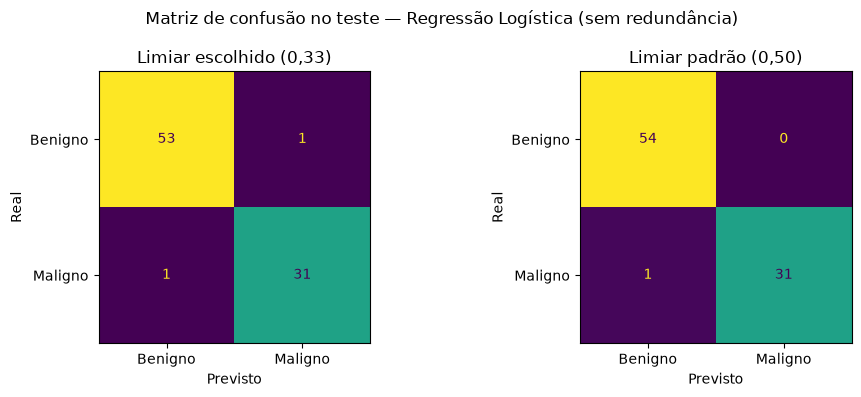

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (titulo, pred) in zip(axes, [(rotulo_limiar, pred_teste), ("Limiar padrão (0,50)", pred_padrao)]):
    ConfusionMatrixDisplay.from_predictions(
        y_teste, pred, labels=CLASSES, display_labels=[NOMES_CLASSES[c] for c in CLASSES],
        colorbar=False, ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")
fig.suptitle(f"Matriz de confusão no teste — {artefato['nome']}")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "matriz_confusao_teste.png", dpi=150)
plt.show()

**Conclusão (teste: 86 exames, 32 malignos):**

| Métrica | Valor | Em palavras |
|---|---|---|
| Recall (M) | **0,969** | encontrou **31 dos 32** malignos (1 falso negativo) |
| Precisão (M) | 0,969 | dos 32 exames sinalizados como malignos, 31 eram (1 falso positivo) |
| F1 / F2 | 0,969 / 0,969 | recall e precisão iguais, então F1 e F2 coincidem |
| Accuracy | 0,977 | acertou 84 dos 86 exames |

- **O resultado é coerente com a validação e com a validação cruzada** (recall entre 0,95 e 1,00). Não há sinal de que o modelo tenha "decorado" o treino.
- **Neste teste, o limiar ajustado não ajudou:** com 0,50, o recall seria o mesmo (0,969) e não haveria falso positivo. O único maligno perdido recebeu probabilidade **0,32**, logo abaixo do limiar de 0,33 (veja a seção 3.2). Na validação, porém, o limiar evitou 1 falso negativo. Com 32 malignos por conjunto, essa diferença de um caso é ruído: o limiar deve ser avaliado em **mais dados** antes de qualquer uso real.
- **Cada caso vale ~3 pontos de recall.** Recall 0,969 não significa "97% garantido": com tão poucos malignos, o valor real pode estar alguns pontos acima ou abaixo.

### 1.1 Curvas ROC e Precisão-Recall

As curvas mostram o modelo em **todos os limiares possíveis ao mesmo tempo**:

- **ROC:** taxa de malignos encontrados (recall) × taxa de benignos sinalizados à toa. A **AUC** (área sob a curva) vai de 0,5 (sorteio) a 1,0 (perfeito). Ela responde: "sorteando um maligno e um benigno, qual a chance de o maligno receber probabilidade maior?".
- **Precisão-Recall:** mais informativa quando a classe positiva é minoria. A **AP** (precisão média) também vai até 1,0.

O ponto preto marca onde o limiar escolhido coloca o modelo.


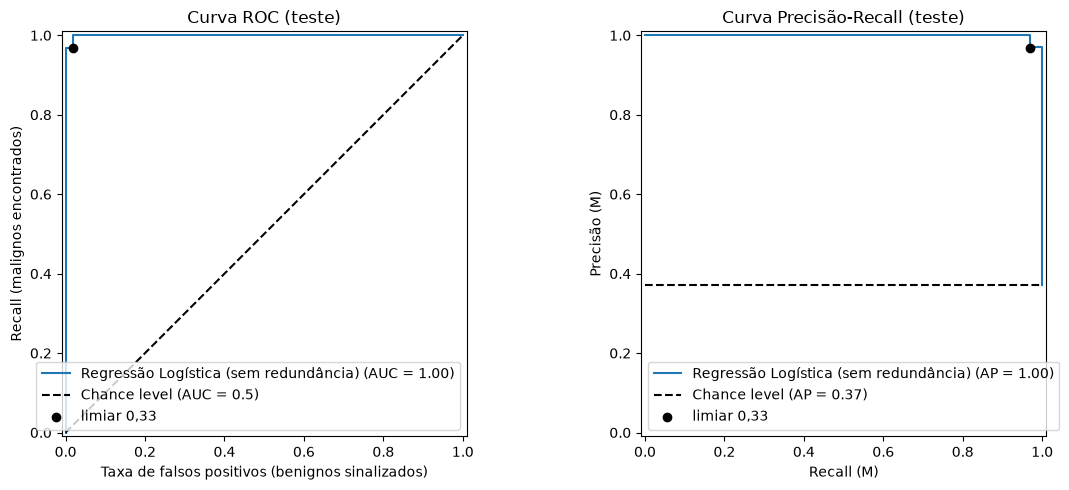

AUC-ROC: 0.9994 | AP (precisão média): 0.9991


In [5]:
y_teste_maligno = (y_teste == CLASSE_POSITIVA).to_numpy()
m = calcular_metricas(y_teste, pred_teste)
taxa_fp = m["Falsos positivos"] / (~y_teste_maligno).sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_teste_maligno, prob_teste, name=artefato["nome"],
                                plot_chance_level=True, ax=axes[0])
axes[0].scatter(taxa_fp, m["Recall (M)"], color="black", zorder=3, label=f"limiar {decimal(limiar)}")
axes[0].set_xlabel("Taxa de falsos positivos (benignos sinalizados)")
axes[0].set_ylabel("Recall (malignos encontrados)")
axes[0].set_title("Curva ROC (teste)")
axes[0].legend(loc="lower right")

PrecisionRecallDisplay.from_predictions(y_teste_maligno, prob_teste, name=artefato["nome"],
                                       plot_chance_level=True, ax=axes[1])
axes[1].scatter(m["Recall (M)"], m["Precisão (M)"], color="black", zorder=3, label=f"limiar {decimal(limiar)}")
axes[1].set_xlabel("Recall (M)")
axes[1].set_ylabel("Precisão (M)")
axes[1].set_title("Curva Precisão-Recall (teste)")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "curvas_roc_pr_teste.png", dpi=150)
plt.show()

print(f"AUC-ROC: {roc_auc_score(y_teste_maligno, prob_teste):.4f} | "
      f"AP (precisão média): {average_precision_score(y_teste_maligno, prob_teste):.4f}")


**Conclusão:** AUC-ROC de **0,999** e AP de **0,999**. O modelo quase sempre dá **probabilidade maior aos malignos do que aos benignos**: ele **ordena** os exames quase perfeitamente. Os dois erros do teste são uma questão de **onde cortar**, não de o modelo "não enxergar" a diferença. É uma boa notícia para a triagem, cujo objetivo principal é ordenar a fila: os casos de maior risco primeiro.

### 1.2 Distribuição das probabilidades e faixa de atenção

Uma probabilidade de 0,32 e outra de 0,99 levam à mesma decisão binária pelo limiar ("benigno" e "maligno"), mas não merecem a mesma confiança. Para o uso prático, propomos **três faixas**, com cortes ilustrativos que devem ser definidos com a equipe clínica:

| Faixa | Probabilidade de maligno | Sugestão de uso |
|---|---|---|
| **Baixa** | < 0,10 | fluxo normal |
| **Atenção** | 0,10 a 0,90 | **revisão prioritária e cuidadosa** pelo médico |
| **Alta** | > 0,90 | prioridade máxima na fila |

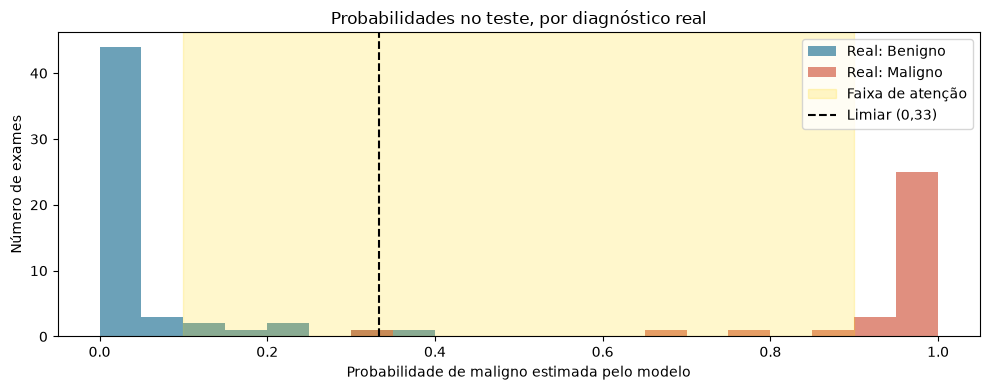

Diagnóstico real,Benigno,Maligno,Total
Faixa,,,
"Baixa (< 0,10)",47,0,47
"Atenção (0,10–0,90)",7,4,11
"Alta (> 0,90)",0,28,28
Total,54,32,86


In [6]:
FAIXAS = [0, 0.10, 0.90, 1]
ROTULOS_FAIXAS = ["Baixa (< 0,10)", "Atenção (0,10–0,90)", "Alta (> 0,90)"]

fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(0, 1, 21)
for classe in CLASSES:
    ax.hist(prob_teste[y_teste.to_numpy() == classe], bins=bins, alpha=0.75,
            color=CORES_CLASSES[classe], label=f"Real: {NOMES_CLASSES[classe]}")
ax.axvspan(FAIXAS[1], FAIXAS[2], color="gold", alpha=0.2, label="Faixa de atenção")
ax.axvline(limiar, color="black", linestyle="--", label=f"Limiar ({decimal(limiar)})")
ax.set_xlabel("Probabilidade de maligno estimada pelo modelo")
ax.set_ylabel("Número de exames")
ax.set_title("Probabilidades no teste, por diagnóstico real")
ax.legend()
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "probabilidades_teste.png", dpi=150)
plt.show()

faixa = pd.Series(pd.cut(prob_teste, FAIXAS, labels=ROTULOS_FAIXAS, include_lowest=True), name="Faixa")
real = pd.Series(y_teste.map(NOMES_CLASSES).to_numpy(), name="Diagnóstico real")
pd.crosstab(faixa, real, margins=True, margins_name="Total")

**Conclusão:**

- A maior parte dos exames recebe probabilidades **perto de 0 ou de 1**: o modelo está "seguro" na maioria dos casos.
- **Os dois erros do teste caíram na faixa de atenção**: o maligno com 0,32 e o benigno com 0,38. Ou seja, um fluxo de três faixas levaria **os dois casos problemáticos para revisão cuidadosa**, em vez de tratá-los como certezas.
- O custo dessa segurança é pequeno: **11 dos 86 exames (13%)** caem na faixa de atenção, sendo 4 malignos e 7 benignos. Os outros 75 ficam em faixas sem nenhum erro: 47 benignos na faixa baixa e 28 malignos na alta.

## 2. Feature importance

Usamos duas visões que se complementam:

1. **Coeficientes da Regressão Logística**: o peso que o modelo deu a cada medida. Como as medidas foram padronizadas, os pesos são comparáveis entre si. **Peso positivo** empurra para maligno; **negativo**, para benigno.
2. **Importância por permutação**: embaralhamos os valores de **uma medida por vez** e vemos **quanto o recall cai**. Se cai muito, o modelo depende dela. Funciona para qualquer modelo e é feita na **validação**, para não reutilizar o teste.

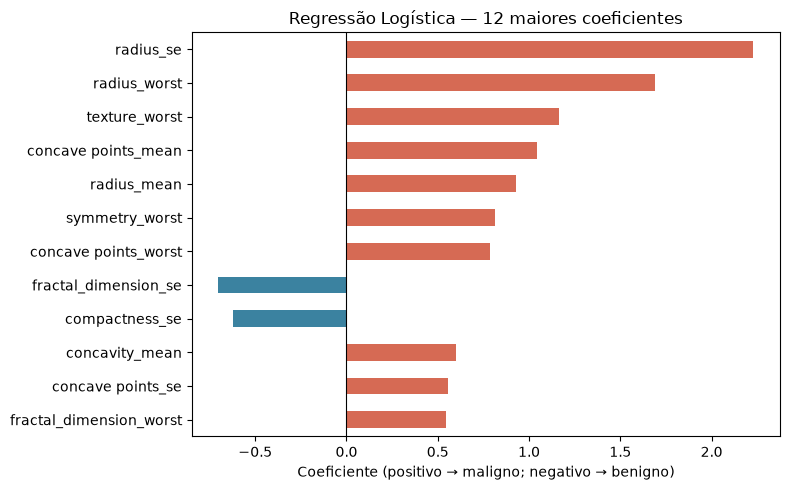

,coeficiente
radius_se,2.228
radius_worst,1.690
texture_worst,1.166
concave points_mean,1.046
radius_mean,0.926
symmetry_worst,0.813
concave points_worst,0.786
fractal_dimension_se,-0.701
compactness_se,-0.622
concavity_mean,0.600


In [8]:
classificador = pipeline.named_steps["classificador"]
colunas_modelo = list(pipeline.named_steps["preprocessador"].get_feature_names_out())
# Esta seção foi escrita para o modelo escolhido no notebook 02 (Regressão Logística).
assert hasattr(classificador, "coef_"), "O vencedor mudou: revise esta seção para o novo modelo."
assert list(classificador.classes_) == CLASSES  # coeficiente positivo => empurra para maligno

coeficientes = pd.Series(classificador.coef_[0], index=colunas_modelo)
top_coef = coeficientes.reindex(coeficientes.abs().sort_values(ascending=False).index).head(12)

fig, ax = plt.subplots(figsize=(8, 5))
top_coef.iloc[::-1].plot.barh(ax=ax, color=[CORES_CLASSES["M"] if v > 0 else CORES_CLASSES["B"]
                                           for v in top_coef.iloc[::-1]])
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Coeficiente (positivo → maligno; negativo → benigno)")
ax.set_title("Regressão Logística — 12 maiores coeficientes")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "coeficientes_modelo_final.png", dpi=150)
plt.show()

top_coef.round(3).rename("coeficiente").to_frame()


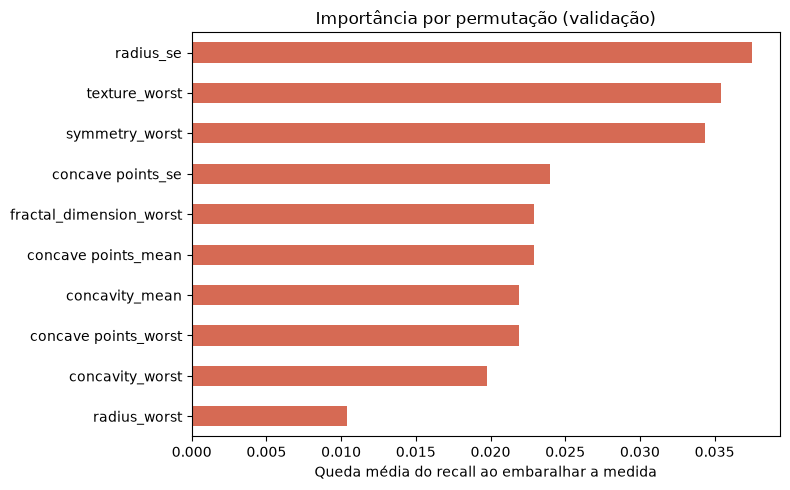

,queda do recall
radius_se,0.0375
texture_worst,0.0354
symmetry_worst,0.0344
concave points_se,0.0240
fractal_dimension_worst,0.0229
concave points_mean,0.0229
concavity_mean,0.0219
concave points_worst,0.0219
concavity_worst,0.0198
radius_worst,0.0104


In [9]:
permutacao = permutation_importance(modelo, divisao.X_val, divisao.y_val, scoring=scorer_recall,
                                    n_repeats=30, random_state=42)
imp_perm = pd.Series(permutacao.importances_mean, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
imp_perm.head(10).iloc[::-1].plot.barh(ax=ax, color=CORES_CLASSES["M"])
ax.set_xlabel("Queda média do recall ao embaralhar a medida")
ax.set_title("Importância por permutação (validação)")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "importancia_permutacao.png", dpi=150)
plt.show()

imp_perm.head(10).round(4).rename("queda do recall").to_frame()

**Conclusão:**

- **Tamanho e irregularidade dominam.** Os maiores pesos positivos são `radius_se` (2,23), `radius_worst` (1,69), `texture_worst` (1,17) e `concave points_mean` (1,05). Núcleos **maiores**, com **tamanho mais variável** entre si, **textura mais heterogênea** e **mais reentrâncias** empurram para maligno, o que é coerente com a citologia e com a EDA.
- **Pesos negativos que surpreendem:** `fractal_dimension_se` (-0,79) e `compactness_se` (-0,62) empurram para **benigno**. Clinicamente, não esperaríamos que "mais irregularidade" indicasse benignidade. A explicação provável é estatística: `compactness_se` tem correlação de ~0,80 com `concavity_se` e `fractal_dimension_se`, e o modelo usa uma para **compensar** a outra. **Esses pesos não devem ser lidos isoladamente.** Remover perímetro e área reduziu a redundância, mas não a eliminou.
- **Na permutação, nenhuma medida isolada é crítica:** a maior queda de recall é de ~0,04 (`radius_se`), cerca de 1 maligno a mais perdido na validação. O modelo distribui a decisão entre várias medidas parecidas: se uma falha, as outras compensam.
- **Importância não é causalidade:** mostra no que o **modelo** se apoia, não o que **causa** o câncer.

## 3. SHAP: por que o modelo decidiu assim?

O **SHAP** distribui a decisão de **cada exame** entre as medidas: quanto cada uma empurrou para maligno (valor positivo) ou para benigno (negativo), partindo da previsão "média" do modelo.

- **Escala:** para a Regressão Logística, o SHAP é calculado em **log-chance** (*log-odds*), a escala em que o modelo soma os pesos. Referências: **0 = 50%** de probabilidade; **-0,69 ≈ 33%** (o nosso limiar); **+2 ≈ 88%**; **-2 ≈ 12%**.
- Usamos o `LinearExplainer`, que é **exato** para modelos lineares. O treino serve de referência ("exame médio"), e explicamos os exames do **teste**.

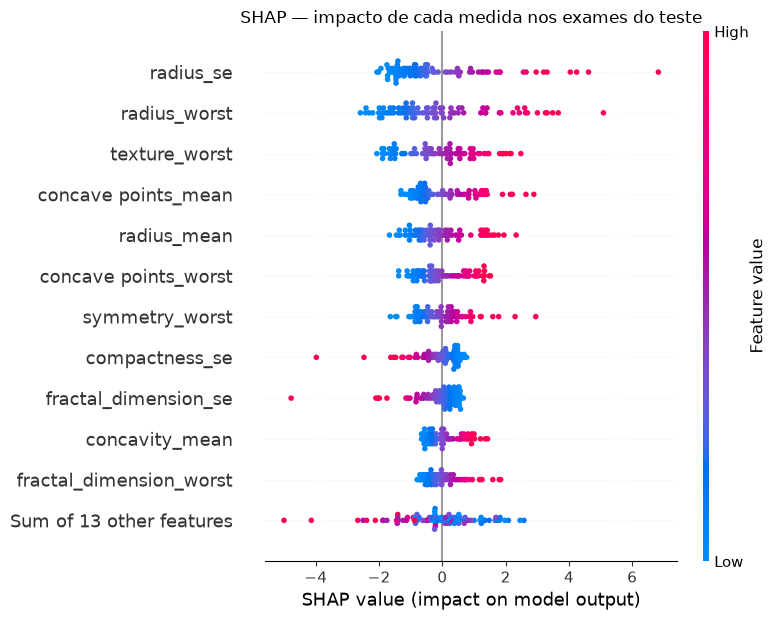

In [10]:
preprocessador = pipeline.named_steps["preprocessador"]
X_treino_transf = pd.DataFrame(preprocessador.transform(divisao.X_treino), columns=colunas_modelo)
X_teste_transf = pd.DataFrame(preprocessador.transform(X_teste), columns=colunas_modelo)

explicador = shap.LinearExplainer(
    classificador, shap.maskers.Independent(X_treino_transf, max_samples=len(X_treino_transf)))
valores_shap = explicador(X_teste_transf)

# Mesmo resultado, mas exibindo os valores ORIGINAIS das medidas (mais fáceis de ler que os padronizados).
explicacao = shap.Explanation(values=valores_shap.values, base_values=valores_shap.base_values,
                              data=X_teste[colunas_modelo].to_numpy(), feature_names=colunas_modelo)

shap.plots.beeswarm(explicacao, max_display=12, show=False)
plt.title("SHAP — impacto de cada medida nos exames do teste")
plt.tight_layout()
plt.savefig(PASTA_FIGURAS / "shap_resumo.png", dpi=150, bbox_inches="tight")
plt.show()

**Como ler o gráfico:** cada ponto é um exame do teste. A posição horizontal é o quanto a medida empurrou aquele exame para **maligno (direita)** ou **benigno (esquerda)**. A cor é o valor da medida: **vermelho = alto**, **azul = baixo**. As medidas estão ordenadas pelo impacto médio.

**Conclusão:**

- Em `radius_se`, `radius_worst`, `texture_worst`, `concave points_mean` e `radius_mean`, os pontos **vermelhos ficam à direita**: valores altos empurram para maligno. É o padrão esperado: núcleos grandes, irregulares e heterogêneos.
- Em `compactness_se` e `fractal_dimension_se`, o padrão se inverte (vermelho à esquerda), o mesmo efeito de compensação visto nos coeficientes. Para a maioria dos exames o impacto é pequeno, mas, quando o valor é extremo, pode pesar muito, como mostra o caso do falso negativo abaixo.
- O SHAP global confirma a importância: **as medidas de tamanho e contorno respondem pela maior parte das decisões**.

### 3.1 Casos individuais

Escolhemos três exames do teste:

- **acertado**: o maligno a que o modelo deu a maior probabilidade;
- **falso negativo**: o maligno que o modelo deixou passar;
- **falso positivo**: o benigno que o modelo sinalizou.

O gráfico *waterfall* parte do valor médio do modelo, **E[f(x)]**, embaixo, e soma, medida por medida, até a previsão daquele exame, **f(x)**, em cima. Barras **vermelhas** empurram para maligno; **azuis**, para benigno. Ao lado de cada medida aparece o valor real do exame.

In [11]:
real_teste = y_teste.to_numpy()
malignos_por_prob = [i for i in np.argsort(-prob_teste) if real_teste[i] == CLASSE_POSITIVA]
casos = {"acertado": malignos_por_prob[0]}
falsos_negativos = np.where((real_teste == CLASSE_POSITIVA) & (pred_teste != CLASSE_POSITIVA))[0]
falsos_positivos = np.where((real_teste != CLASSE_POSITIVA) & (pred_teste == CLASSE_POSITIVA))[0]
if len(falsos_negativos):
    casos["falso_negativo"] = falsos_negativos[0]
if len(falsos_positivos):
    casos["falso_positivo"] = falsos_positivos[0]

pd.DataFrame({
    "Diagnóstico real": [NOMES_CLASSES[real_teste[i]] for i in casos.values()],
    "Previsto": [NOMES_CLASSES[pred_teste[i]] for i in casos.values()],
    "Probabilidade de maligno": [round(prob_teste[i], 3) for i in casos.values()],
}, index=list(casos))

,Diagnóstico real,Previsto,Probabilidade de maligno
acertado,Maligno,Maligno,1.000
falso_negativo,Maligno,Benigno,0.323
falso_positivo,Benigno,Maligno,0.378


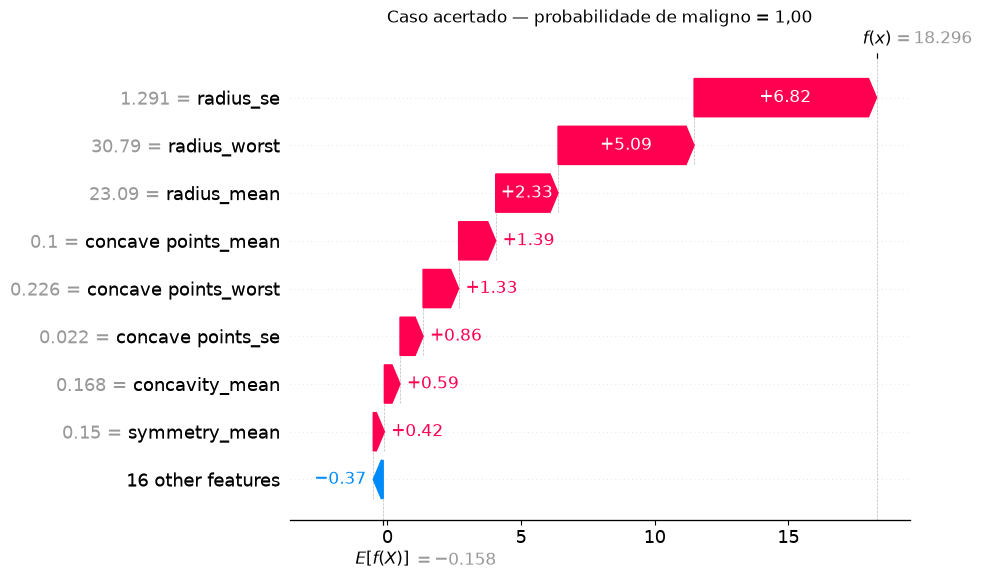

,SHAP (log-chance),valor no exame,média da base
radius_se,6.82,1.2910,0.4052
radius_worst,5.09,30.7900,16.2692
radius_mean,2.33,23.0900,14.1273
concave points_mean,1.39,0.1003,0.0489
concave points_worst,1.33,0.2264,0.1146
concave points_se,0.86,0.0216,0.0118


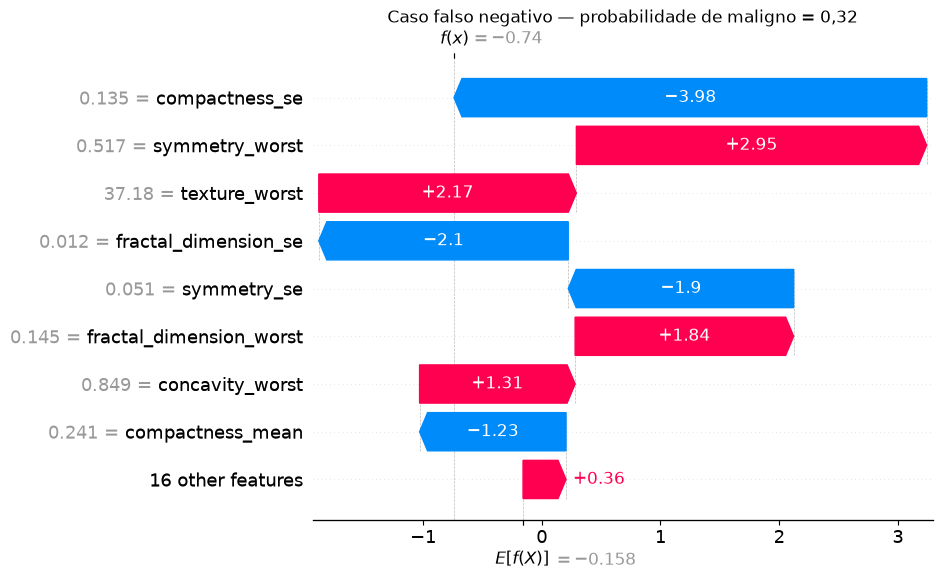

,SHAP (log-chance),valor no exame,média da base
compactness_se,-3.98,0.1354,0.0255
symmetry_worst,2.95,0.5166,0.2901
texture_worst,2.17,37.1800,25.6772
fractal_dimension_se,-2.10,0.0117,0.0038
symmetry_se,-1.90,0.0511,0.0205
fractal_dimension_worst,1.84,0.1446,0.0839


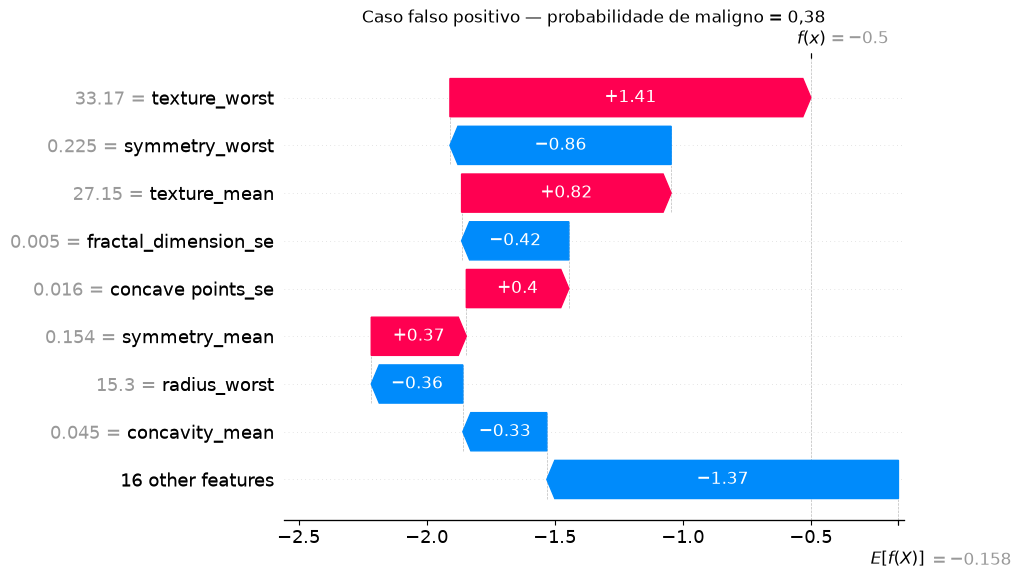

,SHAP (log-chance),valor no exame,média da base
texture_worst,1.41,33.1700,25.6772
symmetry_worst,-0.86,0.2250,0.2901
texture_mean,0.82,27.1500,19.2896
fractal_dimension_se,-0.42,0.0053,0.0038
concave points_se,0.40,0.0163,0.0118
symmetry_mean,0.37,0.1537,0.1812


In [12]:
medias_base = X[colunas_modelo].mean()  # para comparar os valores do exame com o "típico" da base

for nome, i in casos.items():
    shap.plots.waterfall(explicacao[i], max_display=9, show=False)
    plt.title(f"Caso {nome.replace('_', ' ')} — probabilidade de maligno = {decimal(prob_teste[i])}")
    plt.savefig(PASTA_FIGURAS / f"shap_waterfall_{nome}.png", dpi=150, bbox_inches="tight")
    plt.show()

    contrib = pd.Series(explicacao[i].values, index=colunas_modelo)
    principais = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(6)
    display(pd.DataFrame({
        "SHAP (log-chance)": principais.round(2),
        "valor no exame": X_teste.iloc[i][principais.index].round(4),
        "média da base": medias_base[principais.index].round(4),
    }))

### 3.2 O que cada caso nos ensina

Nos três gráficos, o ponto de partida é **E[f(x)] ≈ -0,16** na escala de log-chance, que equivale a ~46% de probabilidade de maligno: a previsão "média" do modelo antes de olhar o exame.

**Caso acertado (maligno, probabilidade ≈ 100%):**

O exame foi classificado como maligno porque os núcleos são **muito grandes e muito variáveis**: `radius_se` = 1,29 (3 vezes a média da base, 0,41), `radius_worst` = 30,8 (média 16,3) e `radius_mean` = 23,1 (média 14,1). Eles também têm **o dobro de reentrâncias** do típico (`concave points_mean` = 0,100 contra 0,049; `concave points_worst` = 0,226 contra 0,115). Todas as medidas principais empurram na mesma direção, e a justificativa é **coerente com a citologia**.

**Caso do falso negativo (maligno, probabilidade 0,32: logo abaixo do limiar de 0,33):**

- Para **maligno** empurraram: `symmetry_worst` = 0,52 (1,8 vez a média; +2,95), `texture_worst` = 37,2 (média 25,7; +2,17) e `fractal_dimension_worst` = 0,145 (média 0,084; +1,84).
- Para **benigno** empurraram, com mais força: `compactness_se` = 0,135, **5 vezes a média** (0,026; -3,98), `fractal_dimension_se` = 0,012, 3 vezes a média (-2,10), e `symmetry_se` = 0,051, 2,5 vezes a média (-1,90).
- **Por que o modelo errou:** este exame tem **valores extremos** justamente nas medidas de variação (`_se`) que receberam peso negativo por compensação estatística (seção 2). Um modelo linear soma os pesos sem limite. Com valores 3 a 5 vezes acima do normal, a compensação, que costuma ser pequena, ficou enorme e anulou os sinais de malignidade.
- **Clinicamente**, a justificativa "a irregularidade varia muito entre os núcleos, logo é benigno" **não faz sentido**. O SHAP é útil exatamente aqui: ele mostra que a decisão se apoiou em medidas com efeito contraintuitivo, um sinal para o médico **desconfiar** do resultado.
- Como a probabilidade ficou em 0,32, o exame cai na **faixa de atenção** e iria para revisão cuidadosa no fluxo proposto.

**Caso do falso positivo (benigno, probabilidade 0,38):**

O motivo principal é a **textura muito heterogênea**: `texture_worst` = 33,2 (média 25,7; +1,41) e `texture_mean` = 27,2 (média 19,3; +0,82). Nenhuma medida de tamanho aparece entre as principais, e a simetria abaixo da média puxou para benigno (-0,86). Os empurrões são **moderados**, e a probabilidade ficou na **faixa de atenção**. O custo desse erro é uma revisão ou exame a mais para uma paciente sem câncer: indesejável, mas bem menos grave que um falso negativo.

**Lições dos três casos:**

- Quando a explicação bate com o conhecimento clínico (caso acertado), ela **reforça a confiança**. Quando se apoia em pesos contraintuitivos (falso negativo), é um **alerta**.
- Os dois erros tiveram probabilidade intermediária (0,32 e 0,38). O modelo "sabia" que estava em dúvida, e é por isso que a faixa de atenção é útil.
- O SHAP explica o **modelo**, não a **biologia do tumor**. Ele mostra em que o modelo se apoiou, não por que o tumor é maligno.

## 4. Discussão crítica: o modelo pode de fato ser implantado?

### Papel do modelo

**Como apoio à triagem, sim, com ressalvas. Como diagnóstico, não.** O médico continua tendo **a palavra final**. O modelo serve para:

- **ordenar a fila**: exames com maior probabilidade são revisados primeiro (a AUC de 0,999 mostra que ele ordena muito bem);
- **segunda leitura**: um alerta quando a impressão do patologista e o modelo discordam;
- **sinalizar incerteza**: casos na faixa de atenção recebem revisão mais cuidadosa.

### Como seria o fluxo

1. A PAAF é realizada e a imagem do material é digitalizada.
2. O **mesmo software de medição** usado no dataset extrai as 30 medidas do núcleo.
3. O modelo devolve a **probabilidade de maligno**, a **faixa** (baixa / atenção / alta) e a **explicação SHAP** do exame.
4. O médico avalia o exame **com** essas informações, o histórico da paciente e outros exames, e **decide**.
5. O diagnóstico confirmado volta para a base, para acompanhar o desempenho do modelo com o tempo.

A explicação SHAP ajuda o médico a **desconfiar** do modelo: se a justificativa não faz sentido clínico, como no falso negativo acima, é um sinal para olhar o exame com mais cuidado.

### Por que ainda não está pronto para uso real

- **Poucos dados, de uma única origem.** São 569 exames de um único centro (Universidade de Wisconsin, início dos anos 1990). Equipamentos, protocolos de coleta e populações diferentes podem mudar as medidas (*data drift*), e o desempenho pode cair muito fora deste contexto.
- **Dependência do software de medição.** As 30 medidas vêm de um programa específico. Outro software, ou outra calibração, gera números diferentes para o mesmo núcleo.
- **Incerteza estatística.** Com 32 malignos no teste, cada erro vale ~3 pontos de recall. O recall de 0,969 é uma estimativa, não uma garantia.
- **O limiar é uma decisão clínica.** O F2 foi um critério técnico razoável. Na prática, o ponto de corte e as faixas devem ser definidos com a equipe médica, conforme quantos falsos positivos ela consegue revisar.
- **Erros ainda acontecem**, e o falso negativo é o mais grave. Em triagem, isso exige que **nenhum caso seja descartado só pelo modelo**.

### Antes de usar de verdade, seria preciso

- **Validação externa:** testar em dados de outros hospitais e de outras épocas.
- **Estudo prospectivo:** acompanhar o modelo no fluxo real, com os médicos, comparando com o processo atual.
- **Monitoramento contínuo:** medir recall e precisão ao longo do tempo e reavaliar se a distribuição das medidas mudar.
- **Regulação e privacidade:** no Brasil, software com finalidade médica é regulado pela ANVISA (RDC nº 657/2022). Dados de saúde são **dados pessoais sensíveis** pela LGPD (Lei 13.709/2018) e exigem base legal, minimização e controle de acesso. Este projeto usa apenas um dataset **público e anonimizado**.

## Resumo final do projeto

| Pergunta | Resposta |
|---|---|
| Qual problema? | Apoiar a triagem de nódulos de mama (benigno × maligno) a partir de 30 medidas do núcleo celular |
| Qual modelo? | **Regressão Logística sem medidas redundantes** (24 medidas), `C=1`, `class_weight="balanced"`, **limiar 0,33** |
| Por que ele? | Maior recall e F2 na validação, desempate pela validação cruzada; também é o mais fácil de interpretar |
| Como se saiu no teste? | **Recall 0,969** (31 de 32 malignos), precisão 0,969, accuracy 0,977, AUC 0,999 |
| No que ele se baseia? | Tamanho (raio), variação do tamanho, textura e reentrâncias do contorno do núcleo |
| Pode ser usado? | Como **apoio** à triagem e segunda leitura, após validação externa. **O médico decide.** |